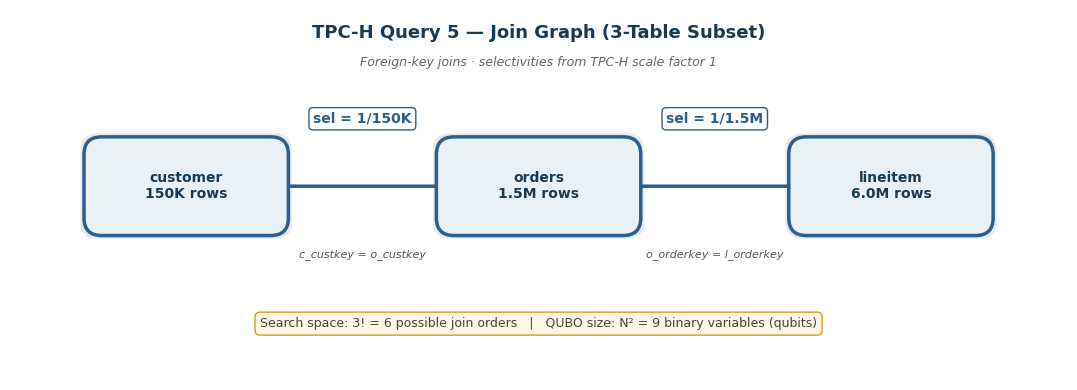

Saved: fig1-joingraph.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import networkx as nx

# Build the join graph with table metadata
tables = {
    'customer':  {'rows': 150_000,    'label': 'customer\n150K rows'},
    'orders':    {'rows': 1_500_000,  'label': 'orders\n1.5M rows'},
    'lineitem':  {'rows': 6_001_215,  'label': 'lineitem\n6.0M rows'},
}

edges = [
    ('customer', 'orders',  '1/150K',     'c_custkey = o_custkey'),
    ('orders',   'lineitem','1/1.5M',     'o_orderkey = l_orderkey'),
]

pos = {
    'customer': (0, 0),
    'orders':   (1, 0),
    'lineitem': (2, 0),
}

# Create figure
fig, ax = plt.subplots(figsize=(11, 4))
fig.patch.set_facecolor('white')

# Draw edges first (so they appear under nodes)
for src, dst, sel, pred in edges:
    x1, y1 = pos[src]
    x2, y2 = pos[dst]
    # Main edge line
    ax.annotate('',
                xy=(x2 - 0.15, y2), xytext=(x1 + 0.15, y1),
                arrowprops=dict(arrowstyle='-', color='#2c5f8d',
                                lw=2.5, shrinkA=0, shrinkB=0))
    # Selectivity label above
    mid_x = (x1 + x2) / 2
    ax.text(mid_x, 0.18, f'sel = {sel}',
            ha='center', fontsize=10, fontweight='bold',
            color='#2c5f8d',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='white',
                      edgecolor='#2c5f8d', lw=1))
    # Join predicate below
    ax.text(mid_x, -0.20, pred,
            ha='center', fontsize=8, style='italic', color='#555')

# Draw nodes as rounded rectangles
for name, info in tables.items():
    x, y = pos[name]
    # Outer shadow box
    shadow = FancyBboxPatch((x - 0.28, y - 0.13),
                             0.56, 0.26,
                             boxstyle='round,pad=0.02,rounding_size=0.05',
                             facecolor='#c8c8c8', edgecolor='none', alpha=0.4,
                             zorder=2)
    ax.add_patch(shadow)
    # Main box
    box = FancyBboxPatch((x - 0.27, y - 0.12),
                          0.54, 0.24,
                          boxstyle='round,pad=0.02,rounding_size=0.05',
                          facecolor='#e8f1f8', edgecolor='#2c5f8d', lw=2.5,
                          zorder=3)
    ax.add_patch(box)
    # Label inside
    ax.text(x, y, info['label'],
            ha='center', va='center',
            fontsize=10, fontweight='bold', color='#1a3a52',
            zorder=4)

# Title and metadata
ax.text(1, 0.42, 'TPC-H Query 5 — Join Graph (3-Table Subset)',
        ha='center', fontsize=13, fontweight='bold', color='#1a3a52')
ax.text(1, 0.34, 'Foreign-key joins · selectivities from TPC-H scale factor 1',
        ha='center', fontsize=9, style='italic', color='#666')

# Annotation: search space size
ax.text(1, -0.40,
        'Search space: 3! = 6 possible join orders   |   QUBO size: N² = 9 binary variables (qubits)',
        ha='center', fontsize=9, color='#444',
        bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='#fef9e7',
                  edgecolor='#d4a017', lw=1))

ax.set_xlim(-0.5, 2.5)
ax.set_ylim(-0.55, 0.5)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.savefig('fig1-joingraph.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: fig1-joingraph.png")

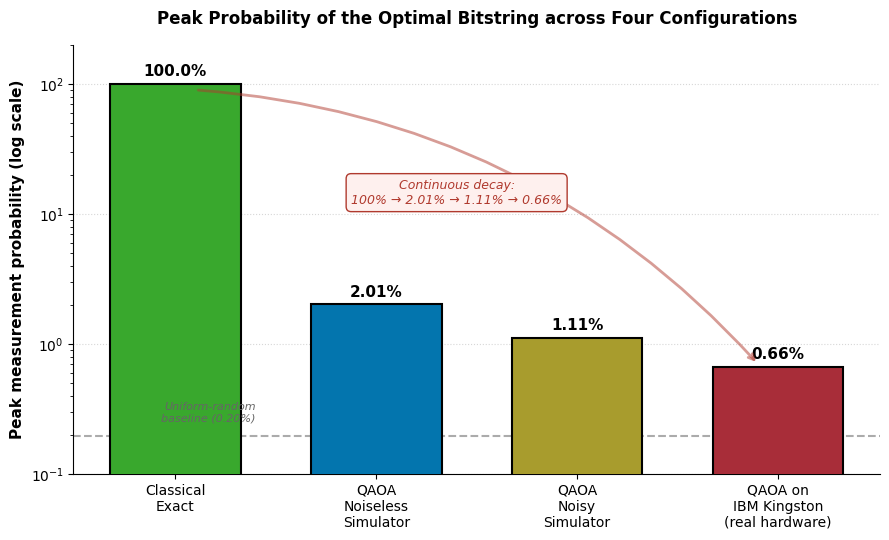

Saved: fig2-probability-comparison.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Your four data points
configurations = ['Classical\nExact', 'QAOA\nNoiseless\nSimulator',
                  'QAOA\nNoisy\nSimulator', 'QAOA on\nIBM Kingston\n(real hardware)']
peak_probs = [100.0, 2.01, 1.11, 0.66]
colors = ['#39A82D', '#0375AE', '#A89C2D', '#A82D39']

# Uniform-random baseline for 9-qubit system
uniform_baseline = 100 / 512  # ≈ 0.195%

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor('white')

x_pos = np.arange(len(configurations))
bars = ax.bar(x_pos, peak_probs, color=colors, edgecolor='black',
              linewidth=1.5, width=0.65, zorder=3)

# Add probability values on top of each bar
for i, (bar, prob) in enumerate(zip(bars, peak_probs)):
    height = bar.get_height()
    if prob >= 10:
        label = f'{prob:.1f}%'
    else:
        label = f'{prob:.2f}%'
    ax.text(bar.get_x() + bar.get_width() / 2, height * 1.15,
            label, ha='center', fontsize=11, fontweight='bold')

# Uniform random baseline line
ax.axhline(y=uniform_baseline, color='#888', linestyle='--', linewidth=1.5,
           alpha=0.7, zorder=2)
ax.text(0.4, uniform_baseline * 1.3, f'Uniform-random\nbaseline (0.20%)',
        fontsize=8, color='#666', ha='right', style='italic')

# Log scale because numbers span huge range
ax.set_yscale('log')
ax.set_ylim(0.1, 200)

# Labels and title
ax.set_xticks(x_pos)
ax.set_xticklabels(configurations, fontsize=10)
ax.set_ylabel('Peak measurement probability (log scale)', fontsize=11, fontweight='bold')
ax.set_title('Peak Probability of the Optimal Bitstring across Four Configurations',
             fontsize=12, fontweight='bold', pad=15)

# Annotation arrow showing the decay
ax.annotate('', xy=(2.9, 0.7), xytext=(0.1, 90),
            arrowprops=dict(arrowstyle='->', color='#b03a2e',
                            lw=2, alpha=0.5,
                            connectionstyle='arc3,rad=-0.2'))
ax.text(1.4, 12, 'Continuous decay:\n100% → 2.01% → 1.11% → 0.66%',
        fontsize=9, color='#b03a2e', ha='center', style='italic',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#fef0ee',
                  edgecolor='#b03a2e', lw=1))

# Grid
ax.yaxis.grid(True, linestyle=':', alpha=0.5, zorder=1)
ax.set_axisbelow(True)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig2-probability-comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: fig2-probability-comparison.png")

Crossover 1 — DP beats exhaustive   at N = 7
Crossover 2 — QAOA gates < DP ops  at N = 9


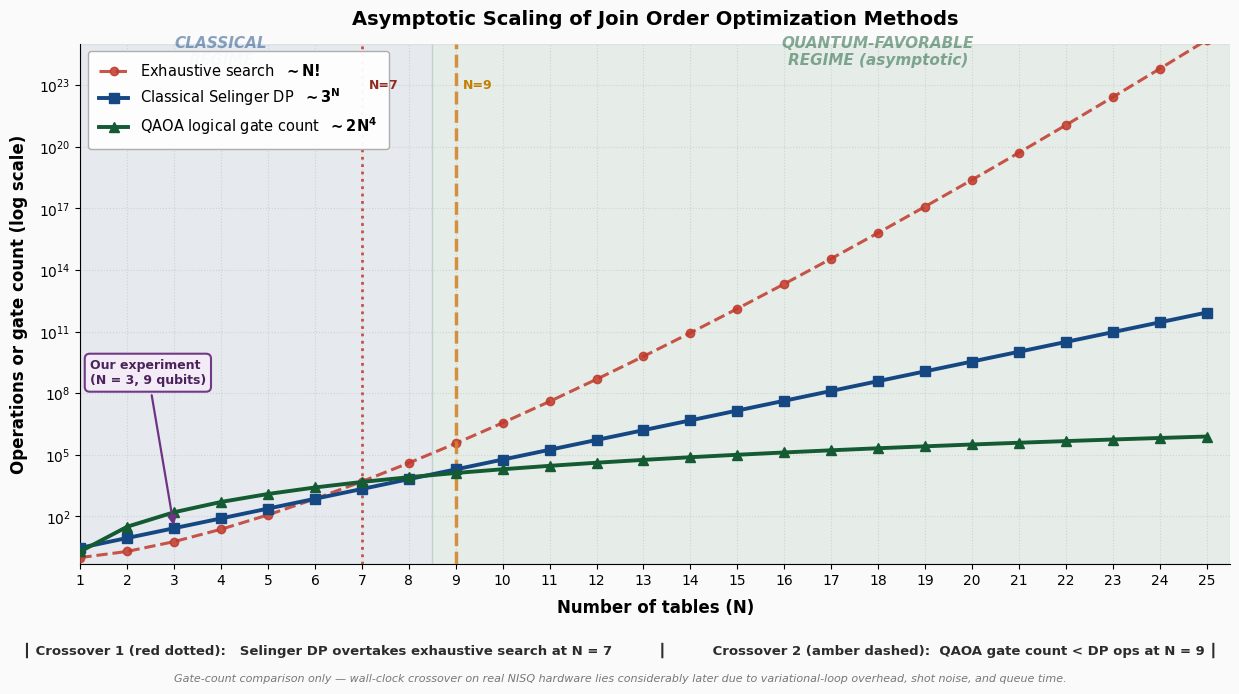

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from math import factorial

Ns = np.arange(1, 26)
exhaustive = np.array([float(factorial(int(n))) for n in Ns])
classical_dp = 3.0 ** Ns
qaoa_gates = 2.0 * Ns ** 4

# ── Fix: find PERMANENT QAOA crossover ──────────────────────────────
# (last N where QAOA is still ABOVE DP, then +1 = first N where QAOA wins)
exh_vs_dp   = np.where(exhaustive > classical_dp)[0]
qaoa_above  = np.where(qaoa_gates > classical_dp)[0]
crossover_exh  = int(Ns[exh_vs_dp[0]])    if len(exh_vs_dp)  > 0 else None
crossover_qaoa = int(Ns[qaoa_above[-1]])+1 if len(qaoa_above) > 0 else None

print(f"Crossover 1 — DP beats exhaustive   at N = {crossover_exh}")
print(f"Crossover 2 — QAOA gates < DP ops  at N = {crossover_qaoa}")

fig, ax = plt.subplots(figsize=(12.5, 7))
fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#fafafa')

# ── Shaded regime backgrounds ────────────────────────────────────────
ax.axvspan(1,                    crossover_qaoa-0.5, alpha=0.09, color='#1f4e79', zorder=1)
ax.axvspan(crossover_qaoa-0.5,   25.5,               alpha=0.09, color='#1d6b3e', zorder=1)

# ── Curves ───────────────────────────────────────────────────────────
ax.plot(Ns, exhaustive,   'o--', label='Exhaustive search  $\\mathbf{\\sim N!}$',
        color='#c0392b', linewidth=2.2, markersize=6, alpha=0.85, zorder=4)
ax.plot(Ns, classical_dp, 's-',  label='Classical Selinger DP  $\\mathbf{\\sim 3^N}$',
        color='#154883', linewidth=2.8, markersize=7, zorder=5)
ax.plot(Ns, qaoa_gates,   '^-',  label='QAOA logical gate count  $\\mathbf{\\sim 2N^4}$',
        color='#145a32', linewidth=2.8, markersize=7, zorder=5)

# ── Crossover vertical lines (NO boxes inside graph) ─────────────────
# Line 1 — red dotted
ax.axvline(x=crossover_exh,  linestyle=':',  color='#c0392b',
           linewidth=2.0, zorder=3, alpha=0.85)
# Line 2 — amber dashed
ax.axvline(x=crossover_qaoa, linestyle='--', color='#d4862a',
           linewidth=2.5, zorder=4, alpha=0.9)

# Tiny N-value labels AT TOP EDGE of plot (above all curves, below regime text)
ax.text(crossover_exh + 0.15,  2e23,
        f'N={crossover_exh}',
        fontsize=9, fontweight='bold', color='#922b21',
        va='top', ha='left', zorder=10)
ax.text(crossover_qaoa + 0.15, 2e23,
        f'N={crossover_qaoa}',
        fontsize=9, fontweight='bold', color='#c47e00',
        va='top', ha='left', zorder=10)

# ── Our experiment — far left, won't overlap anything ────────────────
ax.annotate(
    'Our experiment\n(N = 3, 9 qubits)',
    xy=(3, 3**3), xytext=(1.2, 1e9),
    fontsize=9, fontweight='bold', color='#4a235a',
    ha='left', va='center',
    arrowprops=dict(arrowstyle='-|>', color='#6c3483',
                    lw=1.6, mutation_scale=13),
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#f4ecf7',
              edgecolor='#6c3483', lw=1.5, alpha=0.97),
    zorder=10)

# ── Regime labels — top area where no curve reaches ──────────────────
ax.text(4,   1e24, 'CLASSICAL\nREGIME',
        ha='center', fontsize=11, fontweight='bold',
        color='#154883', alpha=0.5, style='italic')
ax.text(18,  1e24, 'QUANTUM-FAVORABLE\nREGIME (asymptotic)',
        ha='center', fontsize=11, fontweight='bold',
        color='#145a32', alpha=0.5, style='italic')

# ── Axes ─────────────────────────────────────────────────────────────
ax.set_yscale('log')
ax.set_ylim(0.5, 1e25)
ax.set_xlim(1, 25.5)
ax.set_xticks(range(1, 26))
ax.tick_params(axis='both', labelsize=10)
ax.set_xlabel('Number of tables (N)', fontsize=12, fontweight='bold', labelpad=8)
ax.set_ylabel('Operations or gate count (log scale)',
              fontsize=12, fontweight='bold', labelpad=8)
ax.set_title('Asymptotic Scaling of Join Order Optimization Methods',
             fontsize=14, fontweight='bold', pad=14)

# ── Legend ───────────────────────────────────────────────────────────
ax.legend(loc='upper left', fontsize=10.5, framealpha=0.95,
          edgecolor='#aaa', fancybox=True, borderpad=0.8)

# ── Grid / spines ────────────────────────────────────────────────────
ax.grid(True, linestyle=':', alpha=0.35, which='both', zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Bottom footnote — ALL crossover info OUTSIDE the axes ────────────
fig.text(
    0.5, 0.058,
    f'┃ Crossover 1 (red dotted):   Selinger DP overtakes exhaustive search at N = {crossover_exh}'
    f'          ┃          '
    f'Crossover 2 (amber dashed):  QAOA gate count < DP ops at N = {crossover_qaoa} ┃',
    ha='center', fontsize=9.5, fontweight='bold', color='#2c2c2c')

fig.text(
    0.5, 0.018,
    'Gate-count comparison only — wall-clock crossover on real NISQ hardware lies '
    'considerably later due to variational-loop overhead, shot noise, and queue time.',
    ha='center', fontsize=8, color='#777', style='italic')

plt.tight_layout(rect=[0, 0.09, 1, 1])
plt.savefig('fig3-scaling-comparison.png', dpi=300,
            bbox_inches='tight', facecolor='#fafafa')
plt.show()